# Import

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib

In [8]:
df = pd.read_csv('../data/sleep_data.zip')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  str    
 3   occupation                        15000 non-null  str    
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  mental_fatigue_

In [10]:
df['mental_fatigue_score'].describe()

count    15000.000000
mean         6.873009
std          2.730482
min          1.000000
25%          4.700000
50%          7.380000
75%          9.450000
max         10.000000
Name: mental_fatigue_score, dtype: float64

In [11]:
df_test = df.drop(["gender", "occupation"], axis=1)

In [12]:

corr = df_test.corr()

<Axes: >

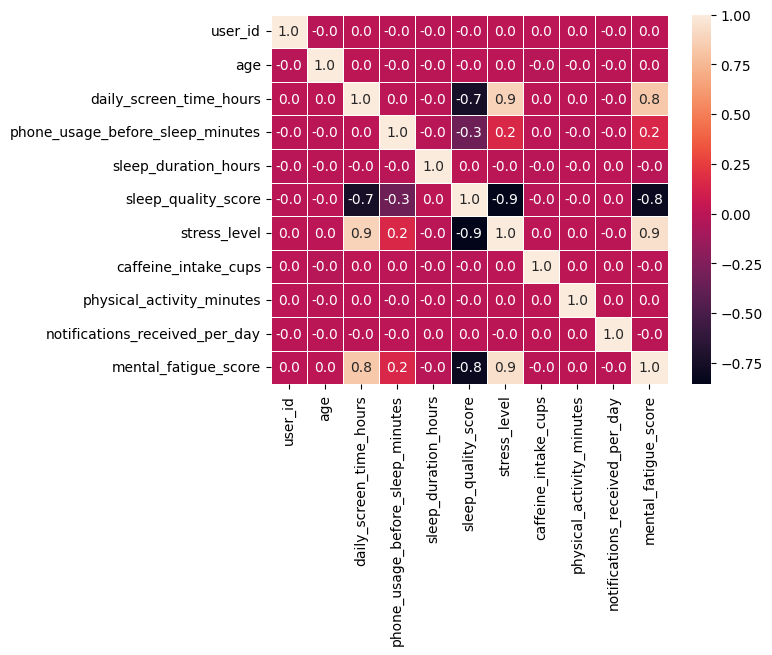

In [13]:
sns.heatmap(corr, annot=True, linewidth=.5, fmt=".1f")

# EDA & Feature Engineering

On enlève stress_level et sleep_quality_score car trop corrélés avec mental_fatigue_score

In [39]:
df = df.drop(["stress_level", "sleep_quality_score"], axis=1)

#### Analyse des features catégorielles

In [40]:
df["gender"].unique()

<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

In [41]:
df["occupation"].unique()

<StringArray>
[         'Designer',           'Teacher', 'Software Engineer',
           'Manager',           'Student',        'Freelancer',
            'Doctor',        'Researcher']
Length: 8, dtype: str

In [42]:
df.groupby("gender")["mental_fatigue_score"].mean()

gender
Female    6.851519
Male      6.893067
Other     6.888752
Name: mental_fatigue_score, dtype: float64

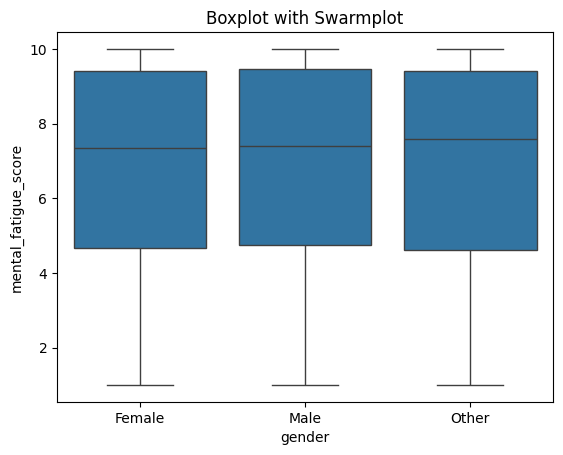

In [43]:
sns.boxplot(data=df, x="gender", y="mental_fatigue_score")
plt.title('Boxplot with Swarmplot')
plt.show()

In [44]:
df.groupby("occupation")["mental_fatigue_score"].mean()

occupation
Designer             6.745571
Doctor               6.872877
Freelancer           6.810153
Manager              6.966682
Researcher           6.804415
Software Engineer    6.920292
Student              7.042198
Teacher              6.810056
Name: mental_fatigue_score, dtype: float64

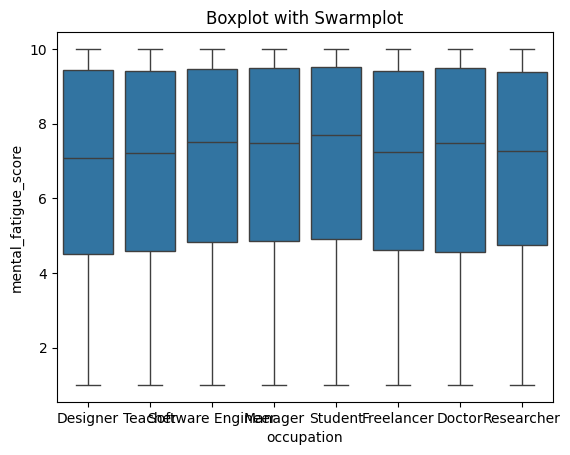

In [45]:
sns.boxplot(data=df, x="occupation", y="mental_fatigue_score")
plt.title('Boxplot with Swarmplot')
plt.show()

##### Décision : exclusion de `gender` et `occupation`
Les boxplots et moyennes par groupe montrent une distribution 
quasi-identique de `mental_fatigue_score` entre les catégories.
Ces variables n'apportent pas de signal prédictif — on les exclut.

In [46]:
df = df.drop(["occupation", "gender"], axis=1)

#### Détecter les outliers

In [47]:
# sns.boxplot(data=df_num)
# # Overlays swarm plot over boxplot
# sns.swarmplot(data=df_num, color='black', alpha=0.5)
# plt.title('Boxplot with Swarmplot')
# plt.show()

#### Feature engineering

In [48]:
df["screen_to_sleep_ratio"] = df["daily_screen_time_hours"]/df["sleep_duration_hours"]

In [49]:
df["notif_to_phone_ratio"] = df["notifications_received_per_day"]/df["phone_usage_before_sleep_minutes"]

In [50]:
df[["screen_to_sleep_ratio", "notif_to_phone_ratio", "mental_fatigue_score"]].corr()

,screen_to_sleep_ratio,notif_to_phone_ratio,mental_fatigue_score
screen_to_sleep_ratio,1.000000,-0.004386,0.726753
notif_to_phone_ratio,-0.004386,1.000000,-0.062359
mental_fatigue_score,0.726753,-0.062359,1.000000


- `screen_to_sleep_ratio` : corrélation 0.70 avec la cible → conservée
- `notif_to_phone_ratio` : corrélation -0.06 → exclue, 
  pas de signal malgré l'intuition initiale

In [51]:
df = df.drop(["notif_to_phone_ratio"], axis=1)

# Preprocessing

In [14]:

df_model = df.copy()

df_model["screen_to_sleep_ratio"] = df_model["daily_screen_time_hours"]/df_model["sleep_duration_hours"]

X = df_model.drop(columns=["mental_fatigue_score", "user_id", 
                      "gender", "occupation",
                      "sleep_quality_score", "stress_level"])
y = df_model["mental_fatigue_score"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42)


# Standardisation
scaler = StandardScaler()
scaler.fit(X_train)

# Fit sur train, transform sur train ET test
X_train_stand = scaler.transform(X_train)
X_test_stand = scaler.transform(X_test)

In [ ]:
np.save("../data/X_train.npy", X_train_stand)
np.save("../data/X_test.npy", X_test_stand)
np.save("../data/y_train.npy", y_train)
np.save("../data/y_test.npy", y_test)

joblib.dump(scaler, "models/scaler.joblib")

['../data/scaler.joblib']